# Module 4 — Customer Single View, Segmentation & Recommendation
**MADT6004 Wrap-Up · Brew Lab BKK case**

Khun Ploy: *"Don't tell me about 5,000 customers. Tell me how many real **types** I have, what each one is worth, and what I should put in front of them."*

What you'll do:
1. Build the **Customer Single View (CSV)** — one row per customer, all behavior collapsed.
2. **K-means clustering** with silhouette scoring to pick *k*.
3. Profile each cluster, name them, map to actions.
4. Build a **product co-purchase recommendation** (item-item cosine similarity).
5. Visualize segments × top products as a **network graph**.

## 1. Setup

In [ ]:
# Bootstrap — pulls the dataset and installs deps when the notebook is opened in Colab.
# Local Jupyter runs from .../notebooks/ and finds ../data/brewlab.db directly, so this is a no-op.
import os
if not os.path.exists("../data/brewlab.db"):
    if not os.path.exists("MADT6004"):
        os.system("git clone -q https://github.com/thanachart/MADT6004.git")
    os.system("pip install -q -r 'MADT6004/Integrated Data Analytics Exercise/requirements.txt'")
    os.chdir("MADT6004/Integrated Data Analytics Exercise/notebooks")

In [1]:
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

conn = sqlite3.connect("../data/brewlab.db")

## 2. Customer Single View — one row per customer

In [2]:
SNAPSHOT = "2026-04-30"

csv_df = pd.read_sql(f'''
WITH txn AS (
  SELECT customer_id,
         COUNT(*)                                 AS frequency,
         SUM(total)                               AS monetary,
         AVG(total)                               AS avg_ticket,
         julianday('{SNAPSHOT}') - julianday(MAX(date(datetime))) AS recency,
         julianday(MAX(date(datetime))) - julianday(MIN(date(datetime))) AS active_span,
         SUM(CASE WHEN channel='app'      THEN 1 ELSE 0 END)*1.0/COUNT(*) AS app_share,
         SUM(CASE WHEN channel='delivery' THEN 1 ELSE 0 END)*1.0/COUNT(*) AS delivery_share,
         SUM(CASE WHEN channel='dine-in'  THEN 1 ELSE 0 END)*1.0/COUNT(*) AS dinein_share,
         SUM(CASE WHEN promo_id IS NOT NULL THEN 1 ELSE 0 END)*1.0/COUNT(*) AS promo_share,
         SUM(CASE WHEN strftime('%w', date(datetime)) IN ('0','6') THEN 1 ELSE 0 END)*1.0/COUNT(*) AS weekend_share
  FROM transactions
  GROUP BY customer_id
),
basket AS (
  SELECT customer_id, AVG(items_per_order) AS avg_basket_size
  FROM (SELECT t.order_id AS order_id, t.customer_id AS customer_id,
               COUNT(*) AS items_per_order
        FROM order_items oi JOIN transactions t ON oi.order_id = t.order_id
        GROUP BY t.order_id, t.customer_id) AS sub
  GROUP BY customer_id
)
SELECT c.customer_id, c.age_group, c.gender, c.home_district,
       c.acquisition_channel, c.segment AS true_segment,
       julianday('{SNAPSHOT}') - julianday(c.signup_date) AS tenure_days,
       COALESCE(txn.frequency, 0)        AS frequency,
       COALESCE(txn.monetary, 0)         AS monetary,
       COALESCE(txn.avg_ticket, 0)       AS avg_ticket,
       COALESCE(txn.recency, 365)        AS recency,
       COALESCE(txn.app_share, 0)        AS app_share,
       COALESCE(txn.delivery_share, 0)   AS delivery_share,
       COALESCE(txn.dinein_share, 0)     AS dinein_share,
       COALESCE(txn.promo_share, 0)      AS promo_share,
       COALESCE(txn.weekend_share, 0)    AS weekend_share,
       COALESCE(basket.avg_basket_size, 0) AS avg_basket_size
FROM customers c
LEFT JOIN txn USING(customer_id)
LEFT JOIN basket USING(customer_id)
''', conn)
print("Customer Single View:", csv_df.shape)
csv_df.head()

Customer Single View: (5000, 17)


,customer_id,age_group,gender,home_district,acquisition_channel,true_segment,tenure_days,frequency,monetary,avg_ticket,recency,app_share,delivery_share,dinein_share,promo_share,weekend_share,avg_basket_size
0,1,18-24,F,Khlong Toei,walk-in,Casual Drifter,339.0,29,2766.24,95.387586,11.0,0.137931,0.068966,0.517241,0.655172,0.206897,1.310345
1,2,35-44,F,Bang Rak,app-signup,Weekend Bruncher,62.0,15,3276.32,218.421333,1.0,0.066667,0.266667,0.466667,0.200000,0.533333,1.533333
2,3,25-34,M,Sathon,walk-in,Weekend Bruncher,312.0,72,16747.78,232.608056,0.0,0.083333,0.222222,0.527778,0.597222,0.250000,1.375000
3,4,25-34,M,Watthana,walk-in,Casual Drifter,42.0,4,605.34,151.335000,4.0,0.000000,0.000000,0.500000,0.000000,0.500000,1.500000
4,5,18-24,F,Bang Na,promo,App Promo Hunter,169.0,46,8055.36,175.116522,0.0,0.500000,0.195652,0.195652,0.565217,0.173913,1.521739


## 3. Clustering — pick k via silhouette

We cluster on behavioral features only (RFM + channel mix + weekend share). We exclude `true_segment` from the features — it's the engineered label we'll use for *validation*, not training.

Active customers (>=1 visit): 4568


   k  silhouette       inertia
0  2    0.183203  37654.579591
1  3    0.220172  31284.631813
2  4    0.234054  27149.247936
3  5    0.267657  23772.582041
4  6    0.254738  21624.686517
5  7    0.258468  20355.866243
6  8    0.246382  19326.115798


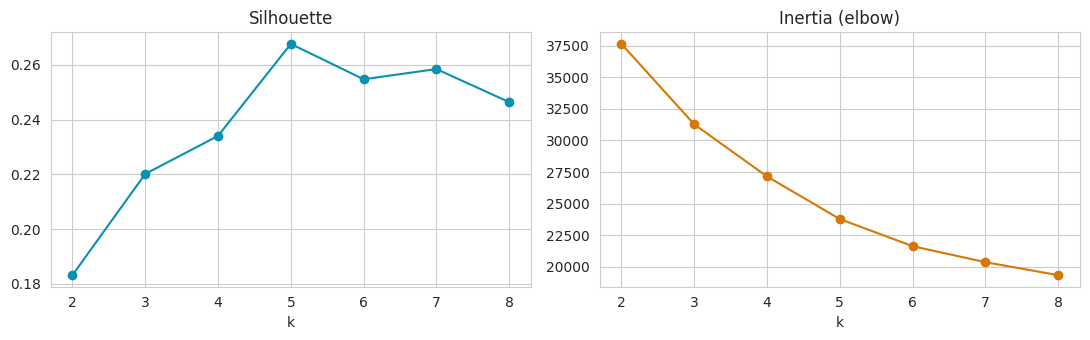

In [3]:
cluster_features = ['recency','frequency','monetary','avg_ticket',
                    'app_share','delivery_share','weekend_share','promo_share',
                    'avg_basket_size','tenure_days']

# Drop customers with no transactions (recency=365, frequency=0)
active = csv_df[csv_df.frequency > 0].copy()
print(f"Active customers (>=1 visit): {len(active)}")

X = StandardScaler().fit_transform(active[cluster_features])

scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    s = silhouette_score(X, km.labels_, sample_size=2000, random_state=42)
    scores.append({"k": k, "silhouette": s, "inertia": km.inertia_})
scores_df = pd.DataFrame(scores)
print(scores_df)

fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
ax[0].plot(scores_df.k, scores_df.silhouette, marker='o', color='#0891B2'); ax[0].set_title("Silhouette"); ax[0].set_xlabel("k")
ax[1].plot(scores_df.k, scores_df.inertia, marker='o', color='#D97706'); ax[1].set_title("Inertia (elbow)"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

In [4]:
K = 4  # or whichever the silhouette suggests
km = KMeans(n_clusters=K, n_init=20, random_state=42).fit(X)
active['cluster'] = km.labels_

profile = active.groupby('cluster')[cluster_features].mean().round(2)
profile['n'] = active.groupby('cluster').size()
profile

,recency,frequency,monetary,avg_ticket,app_share,delivery_share,weekend_share,promo_share,avg_basket_size,tenure_days,n
cluster,,,,,,,,,,,
0,5.14,28.84,3823.28,142.46,0.28,0.11,0.27,0.36,1.33,83.44,999
1,3.21,192.93,23008.91,119.64,0.25,0.05,0.28,0.59,1.31,246.70,606
2,81.64,19.05,2353.39,122.68,0.16,0.05,0.28,0.64,1.29,247.08,1350
3,8.26,59.46,10884.07,190.50,0.31,0.20,0.29,0.59,1.46,231.61,1613


## 4. Name the clusters from their profile

In [5]:
# Use the profile to assign meaningful names
def name_clusters(profile):
    names = {}
    for c, row in profile.iterrows():
        if row['frequency'] > profile['frequency'].quantile(0.7) and row['recency'] < 30:
            names[c] = "Daily Loyalists"
        elif row['weekend_share'] > 0.45 and row['avg_ticket'] > profile['avg_ticket'].mean():
            names[c] = "Weekend Brunchers"
        elif row['app_share'] > 0.5 and row['promo_share'] > profile['promo_share'].mean():
            names[c] = "App Promo Hunters"
        else:
            names[c] = "Casual Drifters"
    return names

cluster_names = name_clusters(profile)
print("Cluster names:")
for k, v in cluster_names.items():
    print(f"  Cluster {k} → {v}")
active['cluster_name'] = active['cluster'].map(cluster_names)

# Validate against engineered labels
print("\nCross-tab cluster_name × true_segment (validation only):")
print(pd.crosstab(active['cluster_name'], active['true_segment']))

Cluster names:
  Cluster 0 → Casual Drifters
  Cluster 1 → Daily Loyalists
  Cluster 2 → Casual Drifters
  Cluster 3 → Casual Drifters

Cross-tab cluster_name × true_segment (validation only):
true_segment     App Promo Hunter  Casual Drifter  Daily Loyalist  \
cluster_name                                                        
Casual Drifters               947            1621             311   
Daily Loyalists                 0               0             606   

true_segment     Weekend Bruncher  
cluster_name                       
Casual Drifters              1083  
Daily Loyalists                 0  


## 5. Visualize segments in PCA space

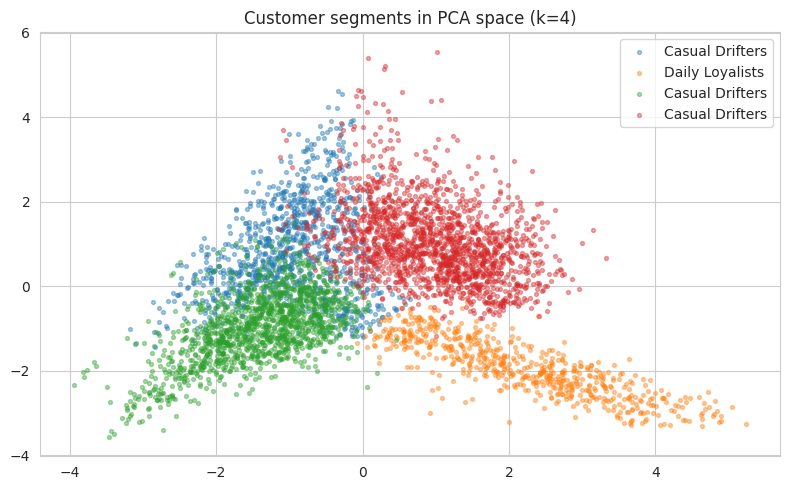

In [6]:
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(X)
fig, ax = plt.subplots(figsize=(8,5))
palette = sns.color_palette("tab10", K)
for i, name in cluster_names.items():
    mask = active['cluster'] == i
    ax.scatter(xy[mask, 0], xy[mask, 1], s=8, alpha=0.4, label=name, color=palette[i])
ax.set_title(f"Customer segments in PCA space (k={K})")
ax.legend()
plt.tight_layout(); plt.show()

## 6. Product recommendation — item-item cosine similarity

In [7]:
# Build customer × product matrix (binary: did they buy it)
cp = pd.read_sql('''
SELECT t.customer_id, oi.product_id, COUNT(*) AS n
FROM transactions t JOIN order_items oi ON t.order_id = oi.order_id
GROUP BY t.customer_id, oi.product_id
''', conn)
matrix = cp.pivot(index='customer_id', columns='product_id', values='n').fillna(0)
matrix_bin = (matrix > 0).astype(int)

# Item-item similarity (cosine)
sim = cosine_similarity(matrix_bin.T)
prod_ids = matrix_bin.columns.tolist()
sim_df = pd.DataFrame(sim, index=prod_ids, columns=prod_ids)

products = pd.read_sql("SELECT product_id, name AS product, category FROM products", conn).set_index('product_id')

def recommend(product_id, n=5):
    sims = sim_df[product_id].drop(product_id).sort_values(ascending=False).head(n)
    return products.loc[sims.index].assign(similarity=sims.values)

# Example: what goes with Latte?
latte_id = products[products['product'] == 'Latte'].index[0]
print(f"Top 5 products co-purchased with Latte:")
print(recommend(latte_id, 5))

Top 5 products co-purchased with Latte:
              product category  similarity
9      Iced Americano   coffee    0.885418
8          Iced Latte   coffee    0.882196
11  Caramel Macchiato   coffee    0.882150
2           Americano   coffee    0.881469
7           Cold Brew   coffee    0.881194


## 7. Top product per segment + recommendation engine

In [8]:
# What does each segment buy most?
seg_buys = pd.read_sql('''
SELECT t.customer_id, oi.product_id, COUNT(*) AS n
FROM transactions t JOIN order_items oi ON t.order_id = oi.order_id
GROUP BY t.customer_id, oi.product_id
''', conn).merge(active[['customer_id','cluster_name']], on='customer_id')

seg_top = (seg_buys.groupby(['cluster_name','product_id'])['n'].sum().reset_index()
           .merge(products.reset_index(), on='product_id'))
top_per_seg = (seg_top.sort_values(['cluster_name','n'], ascending=[True,False])
                       .groupby('cluster_name').head(5))
print("Top 5 products per segment:")
print(top_per_seg.to_string(index=False))

Top 5 products per segment:
   cluster_name  product_id     n           product category
Casual Drifters           4 11537        Cappuccino   coffee
Casual Drifters           7 11431         Cold Brew   coffee
Casual Drifters          11 11333 Caramel Macchiato   coffee
Casual Drifters           1 11323          Espresso   coffee
Casual Drifters          10 11261 Vietnamese Coffee   coffee
Daily Loyalists           7  8393         Cold Brew   coffee
Daily Loyalists           5  8372             Mocha   coffee
Daily Loyalists           6  8370        Flat White   coffee
Daily Loyalists           3  8357             Latte   coffee
Daily Loyalists          11  8321 Caramel Macchiato   coffee


## 8. Network graph — segments ↔ top products

Edges = a segment's top-N products, weighted by purchase volume.
Node size = product popularity (overall) or segment size.

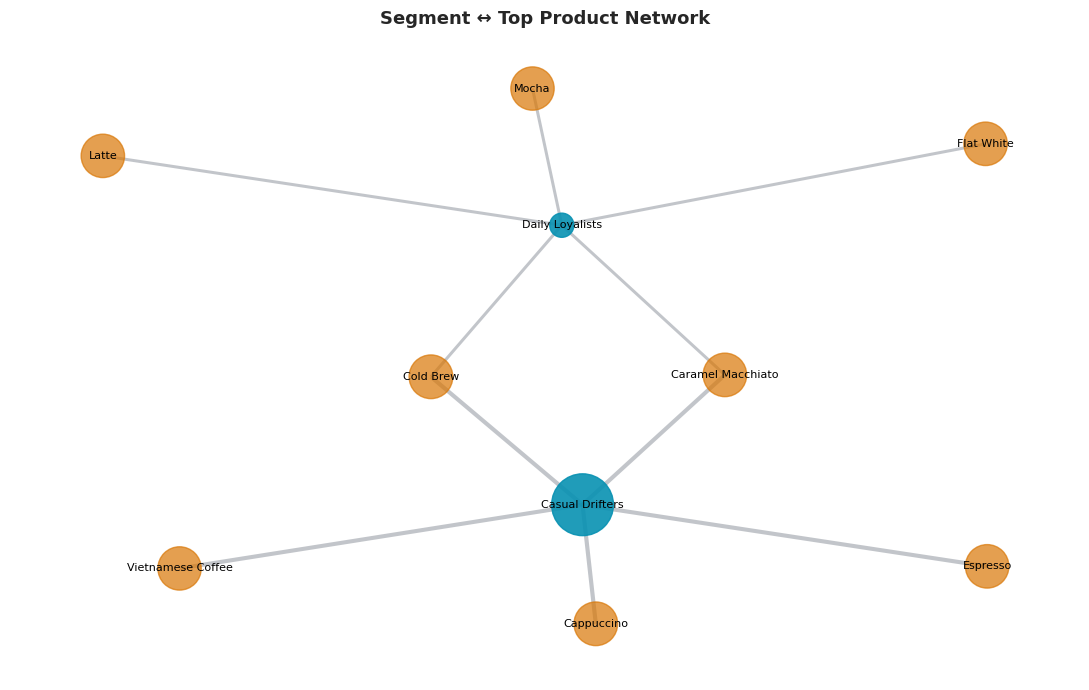

In [9]:
G = nx.Graph()

# Add segment nodes
for seg in cluster_names.values():
    G.add_node(seg, kind='segment', size=int((active['cluster_name']==seg).sum()))

# Add product nodes (only those that appear in any segment's top 5)
top_pids = top_per_seg['product_id'].unique().tolist()
for pid in top_pids:
    name = products.loc[pid, 'product']
    G.add_node(name, kind='product', size=int(seg_buys[seg_buys.product_id==pid]['n'].sum()))

# Edges: segment → top-5 products, weighted
for _, row in top_per_seg.iterrows():
    G.add_edge(row['cluster_name'], row['product'], weight=int(row['n']))

# Layout + draw
fig, ax = plt.subplots(figsize=(11,7))
pos = nx.spring_layout(G, k=0.9, iterations=80, seed=42)
seg_nodes = [n for n,d in G.nodes(data=True) if d['kind']=='segment']
prod_nodes = [n for n,d in G.nodes(data=True) if d['kind']=='product']

nx.draw_networkx_nodes(G, pos, nodelist=seg_nodes,
    node_size=[G.nodes[n]['size']*0.5 for n in seg_nodes],
    node_color="#0891B2", alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=prod_nodes,
    node_size=[G.nodes[n]['size']*0.05 for n in prod_nodes],
    node_color="#D97706", alpha=0.7, ax=ax)
weights = [G[u][v]['weight'] for u,v in G.edges()]
max_w = max(weights) if weights else 1
nx.draw_networkx_edges(G, pos, width=[w/max_w*3 for w in weights],
                       alpha=0.3, edge_color="#374151", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8)

ax.set_title("Segment ↔ Top Product Network", fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()

## 9. Discussion prompts

1. The cross-tab vs the engineered labels — how well did unsupervised clustering recover the latent structure? What does that mean for cases where you don't have a ground truth?
2. The recommender uses **co-purchase** alone. What signal is missing? (Hint: time-of-day, sequence, cold-start.)
3. Look at the network — which products are "bridges" between segments? Those are your **anchor SKUs** for cross-segment campaigns.
4. How would you operationalize this — segment + top-N → which channel?

**Next:** Module 5 — Thai-language reviews. Topics, entities, network graphs of complaint themes.